In [1]:
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
%matplotlib inline

DATA_PATH = 'data/'

In [9]:
def load_and_split_data():
    """
    Loads the raw PCL dataset and filters it to create the official Training set.
    """
    # 1. Load the raw TSV
    column_names = ['par_id', 'art_id', 'keyword', 'country', 'text', 'label']
    
    try:
        # Note: 'error_bad_lines' or 'on_bad_lines' handles potential parsing errors
        df_full = pd.read_csv(
            f'{DATA_PATH}dontpatronizeme_pcl.tsv', 
            sep='\t', 
            skiprows=4,  # Adjust based on your file's specific disclaimer length
            names=column_names, 
            index_col=False,
            on_bad_lines='skip' 
        )
    except FileNotFoundError:
        print("Error: Files not found. Check your DATA_PATH.")
        return None

    # 2. Clean 'label' column and convert to Binary
    # The raw data has labels 0-4. The Spec (Stage 1/2) says:
    # 0-1 = No PCL (0)
    # 2-4 = PCL (1)
    df_full['label'] = pd.to_numeric(df_full['label'], errors='coerce')
    df_full.dropna(subset=['label'], inplace=True)
    df_full['binary_label'] = df_full['label'].apply(lambda x: 1 if x >= 2 else 0)

    # 3. Load the Official Train Split IDs
    try:
        train_ids_df = pd.read_csv(f'{DATA_PATH}train_semeval_parids-labels.csv')
    except FileNotFoundError:
        print("Error: Split file not found.")
        return None

    # 4. Filter: Keep only rows that exist in the Train IDs
    # We convert IDs to string to ensure matching works correctly
    df_full['par_id'] = df_full['par_id'].astype(str)
    train_ids_df['par_id'] = train_ids_df['par_id'].astype(str)
    
    train_df = df_full[df_full['par_id'].isin(train_ids_df['par_id'])].copy()
    
    print(f"Full Data Shape: {df_full.shape}")
    print(f"Training Data Shape: {train_df.shape}")
    
    return train_df

# Run the function
train_df = load_and_split_data()
train_df.head()

Full Data Shape: (10469, 7)
Training Data Shape: (8375, 7)


,par_id,art_id,keyword,country,text,label,binary_label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0,0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0,0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0,0
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0,0


In [10]:
column_names = ['par_id', 'art_id', 'keyword', 'country', 'text', 'label']

df_full = pd.read_csv(
    f'{DATA_PATH}dontpatronizeme_pcl.tsv',
    sep='\t', skiprows=4, names=column_names,
    index_col=False, on_bad_lines='skip'
)
df_full['par_id'] = df_full['par_id'].astype(str)

# Load BOTH split ID files
train_ids_df = pd.read_csv(f'{DATA_PATH}train_semeval_parids-labels.csv')
dev_ids_df   = pd.read_csv(f'{DATA_PATH}dev_semeval_parids-labels.csv')
train_ids_df['par_id'] = train_ids_df['par_id'].astype(str)
dev_ids_df['par_id']   = dev_ids_df['par_id'].astype(str)

train_df_raw = df_full[df_full['par_id'].isin(train_ids_df['par_id'])].copy()
dev_df       = df_full[df_full['par_id'].isin(dev_ids_df['par_id'])].copy()

# Article-level leakage
train_arts = set(train_df_raw['art_id'].unique())
dev_arts   = set(dev_df['art_id'].unique())
overlap    = train_arts & dev_arts

print("=" * 50)
print("1. ARTICLE-LEVEL LEAKAGE")
print(f"   Train articles:                    {len(train_arts)}")
print(f"   Dev articles:                      {len(dev_arts)}")
print(f"   Overlapping articles (both splits): {len(overlap)}")
print(f"   Train rows from overlapping arts:  {(train_df_raw['art_id'].isin(overlap)).sum()}")

# 2. Borderline label=1 noise
df_full['label'] = pd.to_numeric(df_full['label'], errors='coerce')
train_with_raw_labels = df_full[df_full['par_id'].isin(train_ids_df['par_id'])]
label_counts = train_with_raw_labels['label'].value_counts().sort_index()

print("\n" + "=" * 50)
print("2. RAW LABEL DISTRIBUTION (0–4) IN TRAIN SET")
print(label_counts.to_string())
print(f"\n   Borderline (label=1) cases: {int(label_counts.get(1, 0))} rows")
print(f"   These are mapped to No PCL (0) — potential noise")

# 3. Keyword dominance
train_df_raw['label'] = pd.to_numeric(train_df_raw['label'], errors='coerce')
train_df_raw['binary_label'] = train_df_raw['label'].apply(lambda x: 1 if x >= 2 else 0)

print("\n" + "=" * 50)
print("3. KEYWORD DOMINANCE")
print("   Top keywords in PCL examples:")
print(train_df_raw[train_df_raw['binary_label']==1]['keyword'].value_counts().head(10).to_string())
print("\n   Top keywords in No-PCL examples:")
print(train_df_raw[train_df_raw['binary_label']==0]['keyword'].value_counts().head(10).to_string())

# 4. Encoding artifacts
import re
from collections import Counter

def find_artifacts(text):
    issues = []
    if re.search(r'&[a-z]+;|&#\d+;', str(text)):  issues.append('html_entity')
    if re.search(r'\\n|\\t|\\r', str(text)):        issues.append('escape_chars')
    if re.search(r'[^\x00-\x7F]', str(text)):       issues.append('non_ascii')
    if re.search(r'https?://\S+', str(text)):        issues.append('url')
    return issues

train_df_raw['artifacts'] = train_df_raw['text'].apply(find_artifacts)
all_issues = [i for sublist in train_df_raw['artifacts'] for i in sublist]

print("\n" + "=" * 50)
print("4. ENCODING / FORMATTING ARTIFACTS")
print(Counter(all_issues))

for artifact_type in ['html_entity', 'non_ascii', 'url', 'escape_chars']:
    examples = train_df_raw[
        train_df_raw['artifacts'].apply(lambda x: artifact_type in x)
    ]['text'].head(2)
    if len(examples):
        print(f"\n   --- {artifact_type} examples ---")
        for t in examples:
            print(f"   {repr(t[:150])}")

# 5. Empty / very short texts
train_df_raw['word_count'] = train_df_raw['text'].apply(lambda x: len(str(x).split()))

print("\n" + "=" * 50)
print("5. SHORT / EMPTY TEXTS")
empty = train_df_raw[train_df_raw['text'].str.strip() == '']
print(f"   Empty texts: {len(empty)}")
very_short = train_df_raw[train_df_raw['word_count'] < 5]
print(f"   Texts under 5 words: {len(very_short)}")
if len(very_short):
    print(very_short[['text', 'binary_label', 'word_count']].head(10).to_string())

1. ARTICLE-LEVEL LEAKAGE
   Train articles:                    8119
   Dev articles:                      2081
   Overlapping articles (both splits): 107
   Train rows from overlapping arts:  148

2. RAW LABEL DISTRIBUTION (0–4) IN TRAIN SET
label
0    6825
1     756
2     126
3     369
4     299

   Borderline (label=1) cases: 756 rows
   These are mapped to No PCL (0) — potential noise

3. KEYWORD DOMINANCE
   Top keywords in PCL examples:
keyword
homeless         149
in-need          143
poor-families    112
hopeless          98
refugee           73
disabled          67
vulnerable        60
women             38
migrant           31
immigrant         23

   Top keywords in No-PCL examples:
keyword
migrant          851
immigrant        820
vulnerable       811
refugee          807
women            799
disabled         767
homeless         716
in-need          713
hopeless         690
poor-families    607

4. ENCODING / FORMATTING ARTIFACTS
Counter({'html_entity': 65})

   --- html_ent

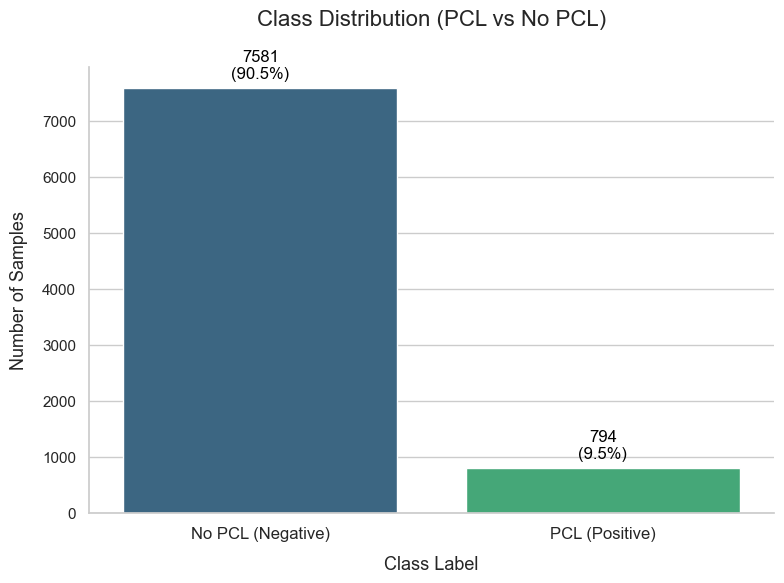

Total: 8375
PCL Count: 794
Ratio: 9.48%


In [20]:
plt.figure(figsize=(8, 6))

# 3. Enhanced Plot
ax = sns.countplot(
    x='binary_label', 
    data=train_df, 
    hue='binary_label', 
    palette='viridis', 
    legend=False
)

# 4. Add clear annotations (Counts & Percentages)
total = len(train_df)
for p in ax.patches:
    height = p.get_height()
    # Calculate percentage
    percentage = '{:.1f}%'.format(100 * height / total)
    # Annotation text: Count + (Percentage)
    ax.annotate(f'{int(height)}\n({percentage})', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

# 5. Beautify Labels and Title
plt.title('Class Distribution (PCL vs No PCL)', fontsize=16, pad=30)
plt.xlabel('Class Label', fontsize=13, labelpad=10)
plt.ylabel('Number of Samples', fontsize=13, labelpad=10)
plt.xticks([0, 1], ['No PCL (Negative)', 'PCL (Positive)'], fontsize=12)
plt.yticks(fontsize=11)

# 6. Remove top and right borders for a cleaner look
sns.despine()

# 7. Save and Show
plt.tight_layout()
plt.savefig('plots/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print stats for your reference
pcl_count = train_df['binary_label'].sum()
print(f"Total: {total}")
print(f"PCL Count: {pcl_count}")
print(f"Ratio: {pcl_count/total:.2%}")

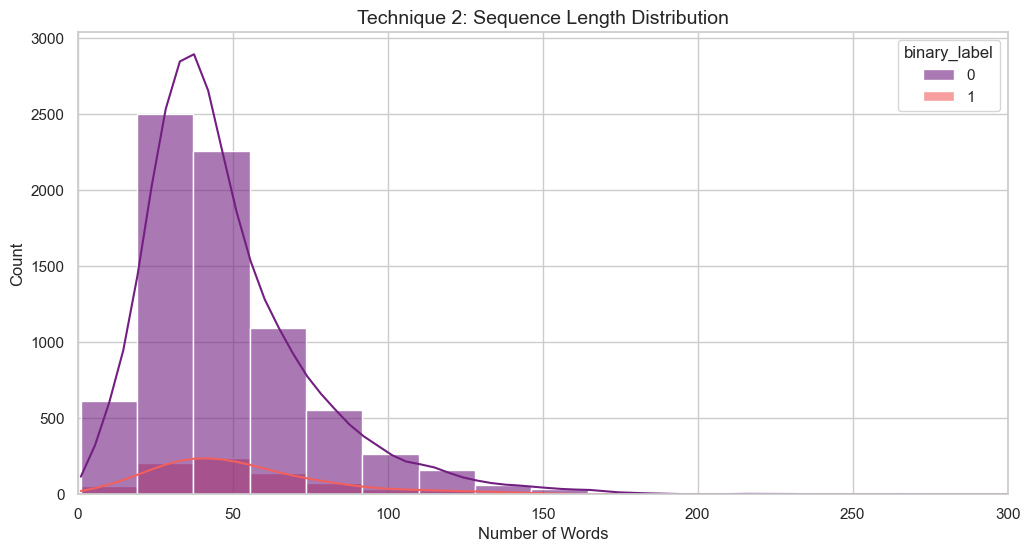

Average Paragraph Length: 48.68 words

Potential Noise (texts < 5 words): 11 rows.
Example noise: ['The Filipino immigrant', 'Volunteer helps earliest refugees', 'UTI in pregnant women', 'refugees', 'Review refugee law']


In [17]:
# Calculate the word count for every paragraph
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 6))

# Plot the distribution of lengths
sns.histplot(
    data=train_df, 
    x='word_count', 
    hue='binary_label', 
    kde=True, 
    bins=50, 
    palette='magma',
    alpha=0.6
)

plt.title('Technique 2: Sequence Length Distribution', fontsize=14)
plt.xlabel('Number of Words', fontsize=12)
plt.xlim(0, 300) # Most news paragraphs are under 300 words
plt.savefig('plots/sequence_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics for the report
avg_len = train_df['word_count'].mean()
print(f"Average Paragraph Length: {avg_len:.2f} words")

# Check for "Noise" (Empty or extremly short texts)
noise = train_df[train_df['word_count'] < 5]
print(f"\nPotential Noise (texts < 5 words): {len(noise)} rows.")
if len(noise) > 0:
    print("Example noise:", noise['text'].head().tolist())

In [21]:
# Calculate average length per class
avg_per_class = train_df.groupby('binary_label')['word_count'].mean()
print(f"Average Length (No PCL): {avg_per_class[0]:.2f} words")
print(f"Average Length (PCL):    {avg_per_class[1]:.2f} words")

Average Length (No PCL): 48.17 words
Average Length (PCL):    53.52 words


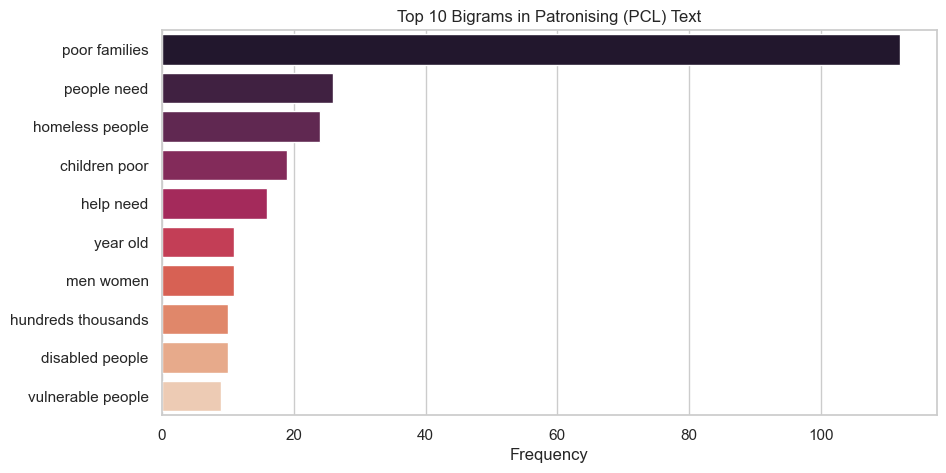

In [18]:
def get_top_ngrams(corpus, n=2, top_k=10):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Get top bigrams (2-word phrases) for PCL examples only
pcl_texts = train_df[train_df['binary_label'] == 1]['text']
top_bigrams = get_top_ngrams(pcl_texts, n=2)

# Unpack for plotting
x, y = zip(*top_bigrams)

# Visualization
plt.figure(figsize=(10, 5))
# FIX: Assigned 'y' to 'hue' and set legend=False to satisfy the warning
sns.barplot(x=list(y), y=list(x), hue=list(x), palette='rocket', legend=False)
plt.title('Top 10 Bigrams in Patronising (PCL) Text')
plt.xlabel('Frequency')
plt.savefig('plots/ngram_plot.png', bbox_inches='tight', dpi=300)
plt.show()